In [1]:
# https://github.com/clovaai/cord
# https://huggingface.co/datasets/naver-clova-ix/cord-v2

from datasets import load_dataset

ds = load_dataset("naver-clova-ix/cord-v2", split="test")

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 100
})


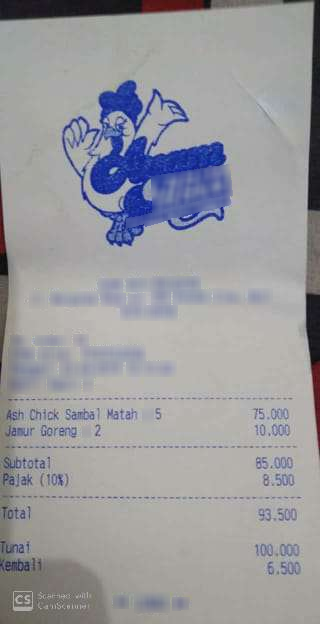

In [2]:
print(ds)
ds[34]["image"]

In [3]:
ds[34]["image"].save("example_cord.png")

In [9]:
ds[34]["image"].size

(320, 624)

In [8]:
ds[65]["image"].size

(960, 1706)

In [8]:
from PIL import Image
ds[65]["image"].thumbnail((800, 800), Image.Resampling.LANCZOS)
# ds[65]["image"]

In [ ]:
ds["ground_truth"][34]

'{"gt_parse": {"menu": [{"nm": "Ash Chick Sambal Matah", "cnt": "5", "price": "75.000"}, {"nm": "Jamur Goreng", "cnt": "2", "price": "10.000"}], "sub_total": {"subtotal_price": "85.000", "tax_price": "8.500"}, "total": {"total_price": "93.500", "cashprice": "100.000", "changeprice": "6.500"}}, "meta": {"version": "2.0.0", "split": "test", "image_id": 34, "image_size": {"width": 320, "height": 624}}, "valid_line": [{"words": [{"quad": {"x2": 26, "y3": 423, "x3": 26, "y4": 423, "x1": 6, "y1": 408, "x4": 6, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "Ash"}, {"quad": {"x2": 61, "y3": 423, "x3": 61, "y4": 423, "x1": 28, "y1": 408, "x4": 28, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "Chick"}, {"quad": {"x2": 105, "y3": 423, "x3": 105, "y4": 423, "x1": 64, "y1": 408, "x4": 64, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "Sambal"}, {"quad": {"x2": 138, "y3": 424, "x3": 138, "y4": 424, "x1": 107, "y1": 408, "x4": 107, "y2": 408}, "is_key": 0, "row_id": 313473, "text": "M

In [ ]:
with open("ground_truth_example.json", "w") as f:
    f.write(ds["ground_truth"][34])

In [2]:
from typing import Optional

from pydantic import BaseModel, Field


class MenuItem(BaseModel):
    nm: Optional[str] = Field(description="Name of menu")
    unitprice: Optional[str] = Field(description="Unit price of menu")
    cnt: Optional[str] = Field(description="Quantity of menu")
    price: Optional[str] = Field(description="Total price of menu")
    # num 	identification # of menu
    # discountprice 	discounted price of menu
    # itemsubtotal 	price of each menu after discount applied
    # vatyn 	whether the price includes tax or not
    # etc 	others
    # sub_nm 	name of submenu
    # sub_num 	identification # of submenu
    # sub_unitprice 	unit price of submenu
    # sub_cnt 	quantity of submenu
    # sub_discountprice 	discounted price of submenu
    # sub_price 	total price of submenu
    # sub_etc 	others


class SubTotal(BaseModel):
    subtotal_price: Optional[str] = Field(description="Subtotal price")
    tax_price: Optional[str] = Field(description="Tax amount")
    service_price: Optional[str] = Field(description="Service charge")
    # discount_price 	discounted price in total
    # subtotal_count 	Total number of items
    # othersvc_price 	added charge other than service charge
    # tax_and_service 	tax + service
    # etc 	others


class Total(BaseModel):
    total_price: Optional[str] = Field(description="Total price")
    cashprice: Optional[str] = Field(description="Amount of price paid in cash")
    changeprice: Optional[str] = Field(description="Amount of change in cash")
    # total_etc 	others
    # creditcardprice 	amount of price paid in credit/debit card
    # emoneyprice 	amount of price paid in emoney, point
    # menutype_cnt 	total count of type of menu
    # menuqty_cnt 	total count of quantity


class Receipt(BaseModel):
    menu: list[MenuItem]
    sub_total: Optional[SubTotal]
    total: Optional[Total]
    # void_total
    # void_menu

In [3]:
import os

from dotenv import load_dotenv
from interfaze import Interfaze

load_dotenv()

interfaze = Interfaze(
    api_key=os.environ["INTERFAZE_API_KEY"],
)

In [46]:
class IDSchema(BaseModel):
    first_name: str = Field(..., description="First name on the ID")
    last_name: str = Field(..., description="Last name on the ID")
    dob: str = Field(..., description="Date of birth on the ID")
    driver_licence_number: str = Field(
        ..., description="Driver licence number on the ID"
    )


response = interfaze.chat.completions.parse(
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Extract the details from this ID"},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": "https://r2public.jigsawstack.com/interfaze/examples/id.jpg"
                    },
                },
            ],
        }
    ],
    response_format=IDSchema,
)

print(response.choices[0].message.parsed)

first_name='IVÁN ICHET' last_name='MUÑOZ ESTRADA' dob='09/12/1987' driver_licence_number='Y4067081'


In [ ]:
with open("api_response_ocr_example.json", "w") as f:
    f.write(response.model_dump_json())

In [4]:
def normalize_text(text: str):
    text = text.lower().strip()
    return text

In [5]:
def get_flattened_word_confidence_dict(precontext: list) -> dict:
    flattened_word_confidence_dict: dict[str, list[tuple[int, float]]] = {}
    index = 0

    for precontext_item in precontext:
        if precontext_item["name"] == "ocr":
            for section in precontext_item["result"]["sections"]:
                for line in section["lines"]:
                    for word in line["words"]:
                        key = normalize_text(word["text"])
                        flattened_word_confidence_dict.setdefault(key, [])
                        flattened_word_confidence_dict[key].append(
                            (index, word["confidence"])
                        )
                        index += 1

    return flattened_word_confidence_dict

In [153]:
flattened_word_confidence_dict = get_flattened_word_confidence_dict(response.precontext)
flattened_word_confidence_dict

{'ash': [(0, 0.99)],
 'chick': [(1, 0.99)],
 'sambal': [(2, 0.94)],
 'matah': [(3, 0.98)],
 '5': [(4, 0.82)],
 '75.000': [(5, 0.99)],
 'jamur': [(6, 0.99)],
 'goreng': [(7, 0.99)],
 '2': [(8, 0.99)],
 '10.000': [(9, 0.85)],
 'subtotal': [(10, 0.99)],
 '85.000': [(11, 0.96)],
 'pajak': [(12, 0.71)],
 '(10%)': [(13, 0.98)],
 '8.500': [(14, 0.92)],
 'total': [(15, 0.99)],
 '93.500': [(16, 0.99)],
 'tunai': [(17, 0.94)],
 '100.000': [(18, 0.95)],
 'kembali': [(19, 0.64)],
 '6.500': [(20, 0.94)],
 'cs': [(21, 0.94)]}

In [6]:
def get_confidence_for_text_in_parsed(
    text: str | int | float,
    flattened_word_confidence_dict: dict,
) -> float | None:
    text = str(text)
    words = [normalize_text(w) for w in text.split() if normalize_text(w)]

    confidence_by_words: dict[str, float] = {}

    for w in words:
        if w not in flattened_word_confidence_dict:
            print(f"Word {w} does not occur")
            return

        # Ignore non unique for now
        if len(flattened_word_confidence_dict[w]) != 1:
            print(f"{w} occurs multiple times {flattened_word_confidence_dict[w]}")
            return

        confidence_by_words[w] = flattened_word_confidence_dict[w][0][1]

    return min(confidence_by_words.values())

In [158]:
get_confidence_for_text_in_parsed("IVAN", flattened_word_confidence_dict)

Word ivan does not occur


In [7]:
def parse_ground_truth_to_pydantic(ground_truth: dict) -> Receipt:
    gt_parse = ground_truth["gt_parse"]
    receipt = Receipt(menu=[], sub_total=None, total=None)
    if "menu" in gt_parse:
        menu = gt_parse["menu"]
        if type(menu) == dict:
            menu = [menu]

        for menu_item in menu:
            receipt.menu.append(
                MenuItem(
                    nm=menu_item.get("nm", None),
                    cnt=menu_item.get("cnt", None),
                    price=menu_item.get("price", None),
                    unitprice=menu_item.get("unitprice", None),
                )
            )

    if "sub_total" in gt_parse:
        sub_total_dict = gt_parse["sub_total"] or {}
        receipt.sub_total = SubTotal(
            subtotal_price=sub_total_dict.get("subtotal_price", None),
            tax_price=sub_total_dict.get("tax_price", None),
            service_price=sub_total_dict.get("service_price", None),
        )

    if "total" in gt_parse:
        total_dict = gt_parse["total"] or {}
        receipt.total = Total(
            total_price=total_dict.get("total_price", None),
            cashprice=total_dict.get("cashprice", None),
            changeprice=total_dict.get("changeprice", None),
        )

    return receipt

In [100]:
import json

receipt = parse_ground_truth_to_pydantic(json.loads(ds[34]["ground_truth"]))
receipt

Receipt(menu=[Menu(nm='Ash Chick Sambal Matah', unitprice=None, cnt='5', price='75.000'), Menu(nm='Jamur Goreng', unitprice=None, cnt='2', price='10.000')], sub_total=SubTotal(subtotal_price='85.000', tax_price='8.500', service_price=None), total=Total(total_price='93.500', cashprice='100.000', changeprice='6.500'))

In [8]:
import base64
import io

from PIL import Image


def image_to_base64(image: Image.Image) -> str:
    buffer = io.BytesIO()

    image.save(buffer, format="png")
    image_bytes = buffer.getvalue()
    base64_img_str = base64.b64encode(image_bytes).decode("utf-8")
    return base64_img_str

In [ ]:
img: Image = ds[2]["image"]
image_to_base64(img)[:45]

'iVBORw0KGgoAAAANSUhEUgAAA2AAAAUQCAIAAACtAqQIA'

In [ ]:
response = interfaze.chat.completions.parse(
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Extract the details from this receipt. Currency are in Indonesian Rupiah",
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{image_to_base64(ds[34]['image'])}"
                    },
                },
            ],
        }
    ],
    response_format=Receipt,
)

print(response.choices[0].message.parsed)

menu=[Menu(nm='Ash Chick Sambal Matah', unitprice=None, cnt='5', price='75.000'), Menu(nm='Jamur Goreng', unitprice=None, cnt='2', price='10.000')] sub_total=SubTotal(subtotal_price='85.000', tax_price='8.500', service_price=None) total=Total(total_price='93.500', cashprice='100.000', changeprice='6.500')


In [144]:
pred_receipt = Receipt.model_validate(response.choices[0].message.parsed, strict=True)
pred_receipt.menu[0]

Menu(nm='Ash Chick Sambal Matah', unitprice=None, cnt='5', price='75.000')

In [9]:
import time


def get_pred_receipt(
    img_uri: str,
) -> dict | None:
    no_of_retries = 3
    for i in range(no_of_retries):
        try:
            response = interfaze.chat.completions.parse(
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": "Extract the details from this receipt. Currency unit is Indonesian Rupiah",
                            },
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": img_uri,
                                },
                            },
                        ],
                    }
                ],
                response_format=Receipt,
            )

            pred_receipt = Receipt.model_validate(
                response.choices[0].message.parsed, strict=True
            )
            return {"receipt": pred_receipt, "precontext": response.precontext}
        except Exception as err:
            print(f"Error while calling interfaze at retry {i}: {err}")
            time.sleep(5)

    return

In [ ]:
import json


def run_ocr():
    sub_dataset = ds.select(range(3))
    result_dict: dict[str, tuple[Receipt, Receipt]] = {}

    for x in sub_dataset:
        img_uri = f"data:image/png;base64,{image_to_base64(x['image'])}"

        ground_truth = json.loads(x["ground_truth"])
        image_id = ground_truth["meta"]["image_id"]
        print(f"image_id: {image_id}")
        ground_truth_receipt = parse_ground_truth_to_pydantic(ground_truth)

        pred_res = get_pred_receipt(img_uri)

        if pred_res is None:
            continue

        result_dict[image_id] = (ground_truth_receipt, pred_res)

    return result_dict

In [11]:
def emit_field_results_from_receipt(
    img_id: str,
    ground_truth_receipt: Receipt,
    pred_res: dict,
) -> list[tuple]:
    field_results = []
    # img_id, category_key, orig_alue, pred_value, confidence
    ground_truth_menu_map = {x.nm: x for x in ground_truth_receipt.menu if x.nm}
    pred_receipt: Receipt = pred_res["receipt"]
    precontext: dict | None = pred_res["precontext"]

    if precontext is None:
        return []

    flattened_word_confidence_dict = get_flattened_word_confidence_dict(precontext)

    for menu_item in pred_receipt.menu:
        nm = normalize_text(menu_item.nm)

        if nm not in ground_truth_menu_map:
            continue

        ground_truth_menu_item = ground_truth_menu_map[nm]

        for k, v in menu_item:
            if v is None:
                continue

            pred_v = normalize_text(v)
            actual_v = getattr(ground_truth_menu_item, k, None)

            confidence = get_confidence_for_text_in_parsed(
                pred_v, flattened_word_confidence_dict
            )

            if confidence is None:
                continue

            field_results.append(
                (
                    img_id,
                    f"menu_item.{k}",
                    actual_v,
                    pred_v,
                    confidence,
                )
            )

    for receipt_k, receipt_v in pred_receipt:
        if receipt_k == "menu":
            continue

        if receipt_v is None:
            continue

        ground_truth_v = getattr(ground_truth_receipt, receipt_k, None)

        for k, v in receipt_v:
            if v is None:
                continue

            pred_v = normalize_text(v)
            actual_v = getattr(ground_truth_v, k, None) if ground_truth_v else None

            confidence = get_confidence_for_text_in_parsed(
                pred_v, flattened_word_confidence_dict
            )

            if confidence is None:
                continue

            field_results.append(
                (
                    img_id,
                    f"{receipt_k}.{k}",
                    actual_v,
                    pred_v,
                    confidence,
                )
            )

    return field_results

In [12]:
def ece_pipeline():
    result_dict = run_ocr()
    field_results = []

    for k, v in result_dict.items():
        field_results.extend(emit_field_results_from_receipt(k, v[0], v[1]))

    return field_results

In [13]:
ece_pipeline()

60.000 occurs multiple times [(5, 0.62), (13, 0.69), (17, 0.83)]
60.000 occurs multiple times [(5, 0.62), (13, 0.69), (17, 0.83)]
91000 occurs multiple times [(9, 1), (11, 1)]
91000 occurs multiple times [(9, 1), (11, 1)]


[(0, 'sub_total.tax_price', '5.455', '5.455', 0.61),
 (2, 'sub_total.subtotal_price', '28,000', '28,000', 0.99),
 (2, 'total.total_price', '28,000', '28.000', 0.63),
 (2, 'total.cashprice', '100,000', '100,000', 0.99),
 (2, 'total.changeprice', '72,000', '72,000', 0.99)]

In [1]:
from pipeline import ece_pipeline

ece_pipeline()

image_id: 0
image_id: 1
image_id: 2
60.000 occurs multiple times [(5, 0.62), (13, 0.69), (17, 0.83), (32, 0.62), (40, 0.69), (44, 0.83), (59, 0.62), (67, 0.69), (71, 0.83), (86, 0.62), (94, 0.69), (98, 0.83)]
5.455 occurs multiple times [(11, 0.61), (38, 0.61), (65, 0.61), (92, 0.61)]
60.000 occurs multiple times [(5, 0.62), (13, 0.69), (17, 0.83), (32, 0.62), (40, 0.69), (44, 0.83), (59, 0.62), (67, 0.69), (71, 0.83), (86, 0.62), (94, 0.69), (98, 0.83)]
91000 occurs multiple times [(9, 1), (11, 1)]
91000 occurs multiple times [(9, 1), (11, 1)]


[(2, 'sub_total.subtotal_price', '28,000', '28,000', 0.99),
 (2, 'total.total_price', '28,000', '28.000', 0.63),
 (2, 'total.cashprice', '100,000', '100,000', 0.99),
 (2, 'total.changeprice', '72,000', '72,000', 0.99)]

In [2]:
field_results = [
    (2, "sub_total.subtotal_price", "28,000", "28,000", 0.99),
    (2, "total.total_price", "28,000", "28.000", 0.63),
    (2, "total.cashprice", "100,000", "100,000", 0.99),
    (2, "total.changeprice", "72,000", "72,000", 0.99),
]

In [ ]:
bins = [round(x * 0.1, 1) for x in range(10)]
bins

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

In [ ]:
import math

field_results_by_bins = [[] for _ in range(10)]

for fr in field_results:
    confidence = round(fr[4], 2)
    index = math.floor(confidence * 10)

    field_results_by_bins[index].append(fr)

In [ ]:
import statistics

ece = 0
for i in range(10):
    if len(field_results_by_bins[i]) == 0:
        continue

    average_confidence = statistics.mean([x[4] for x in field_results_by_bins[i]])
    accuracy = statistics.mean([int(x[2] == x[3]) for x in field_results_by_bins[i]])
    ece += (len(field_results_by_bins[i]) / len(field_results)) * abs(
        average_confidence - accuracy
    )

ece

0.165

In [87]:
import math
import statistics


def calculate_ece(field_results: list[tuple]):
    bins = [round(x * 0.1, 1) for x in range(10)]
    field_results_by_bins = [[] for _ in bins]

    for fr in field_results:
        confidence = round(fr[4], 2)
        index = math.floor(confidence * 10)

        field_results_by_bins[index].append(fr)

    ece = 0
    stats = {
        "accuracies": [],
        "avg_confidences": [],
    }

    for i in range(10):
        if len(field_results_by_bins[i]) == 0:
            stats["accuracies"].append(0)
            stats["avg_confidences"].append(0)
            continue

        average_confidence = statistics.mean([x[4] for x in field_results_by_bins[i]])
        accuracy = statistics.mean(
            [int(x[2] == x[3]) for x in field_results_by_bins[i]]
        )
        ece += (len(field_results_by_bins[i]) / len(field_results)) * abs(
            average_confidence - accuracy
        )

        stats["accuracies"].append(accuracy)
        stats["avg_confidences"].append(average_confidence)

    return {
        "ece": ece,
        "field_results_by_bins": field_results_by_bins,
        "bins": bins,
        "stats": stats,
    }

In [88]:
ece_data = calculate_ece(field_results)
ece_data

{'ece': 0.165,
 'field_results_by_bins': [[],
  [],
  [],
  [],
  [],
  [],
  [(2, 'total.total_price', '28,000', '28.000', 0.63)],
  [],
  [],
  [(2, 'sub_total.subtotal_price', '28,000', '28,000', 0.99),
   (2, 'total.cashprice', '100,000', '100,000', 0.99),
   (2, 'total.changeprice', '72,000', '72,000', 0.99)]],
 'bins': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'stats': {'accuracies': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
  'avg_confidences': [0, 0, 0, 0, 0, 0, 0.63, 0, 0, 0.99]}}

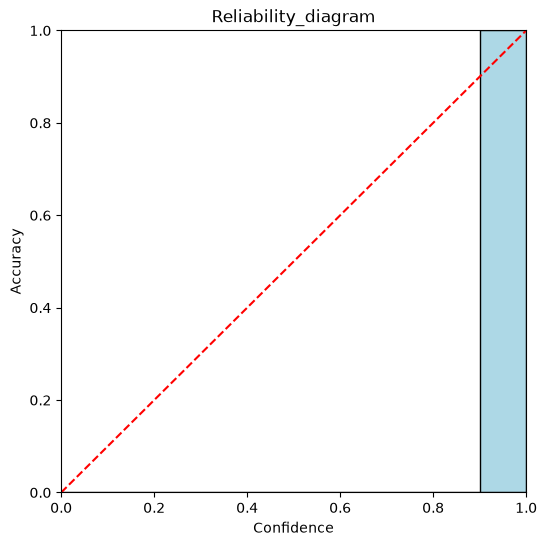

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

ax.bar(
    ece_data["bins"],
    ece_data["stats"]["accuracies"],
    color="lightblue",
    width=0.1,
    align="edge",
    edgecolor="black",
)
ax.plot([0, 1], [0, 1], color="red", linestyle="--")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Reliability_diagram")

plt.show()

In [90]:
ece_data["stats"]["counts"] = [len(ece_data["field_results_by_bins"][i]) for i in range(10)]

In [95]:
[x[4] for x in field_results]

[0.99, 0.63, 0.99, 0.99]

(array([0., 0., 0., 0., 0., 0., 1., 0., 0., 3.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

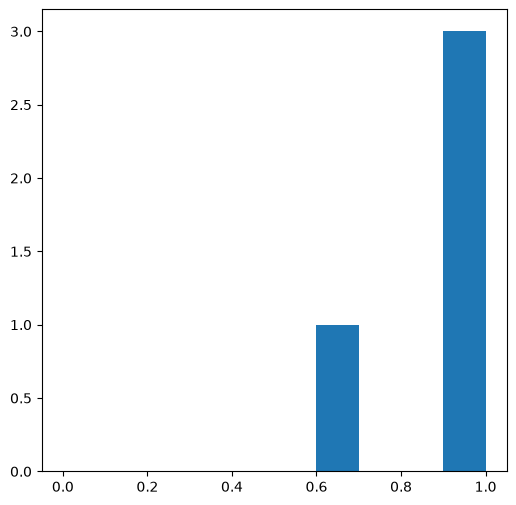

In [97]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.hist([0.99, 0.63, 0.99, 0.99], ece_data["bins"]+[1.0])

image_id: 0 ocr_res_path: assets/ocr_results/0.json
image_id: 1 ocr_res_path: assets/ocr_results/1.json
image_id: 3 ocr_res_path: assets/ocr_results/3.json
image_id: 2 ocr_res_path: assets/ocr_results/2.json
image_id: 4 ocr_res_path: assets/ocr_results/4.json
image_id: 7 ocr_res_path: assets/ocr_results/7.json
image_id: 6 ocr_res_path: assets/ocr_results/6.json
image_id: 9 ocr_res_path: assets/ocr_results/9.json
image_id: 5 ocr_res_path: assets/ocr_results/5.json
image_id: 11 ocr_res_path: assets/ocr_results/11.json
image_id: 10 ocr_res_path: assets/ocr_results/10.json
image_id: 8 ocr_res_path: assets/ocr_results/8.json
image_id: 12 ocr_res_path: assets/ocr_results/12.json
image_id: 15 ocr_res_path: assets/ocr_results/15.json
image_id: 13 ocr_res_path: assets/ocr_results/13.json
image_id: 18 ocr_res_path: assets/ocr_results/18.json
image_id: 14 ocr_res_path: assets/ocr_results/14.json
image_id: 16 ocr_res_path: assets/ocr_results/16.json
image_id: 17 ocr_res_path: assets/ocr_results/17

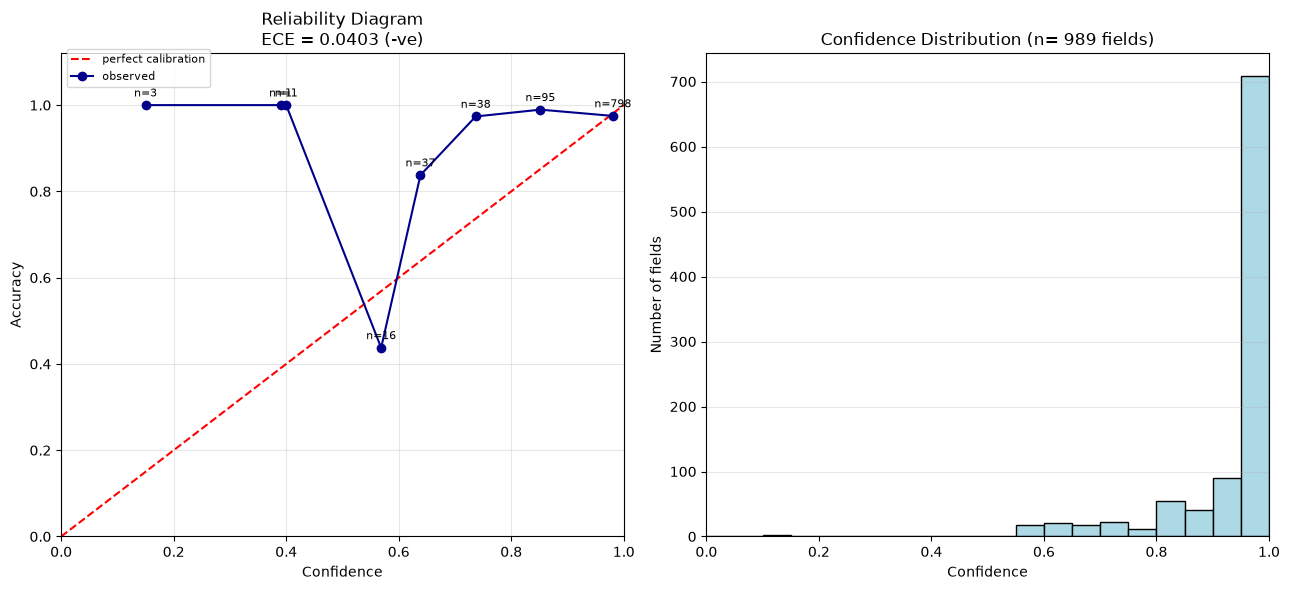

In [1]:
from pipeline import ece_pipeline

ece_pipeline(100)